In [81]:
# imports
import numpy as np
import matplotlib.pyplot as plt

from chebyshev_hofbauer_resonances.general_tent_map.approx_transfer_op import (
    approx_super_adjacency,
    approx_ulams,
)

In [99]:
# function definition
alpha = 1.8
function_domains = [(0, 0.5), (0.5, 1)]
functions = [lambda x: alpha * x, lambda x: alpha * (1 - x)]
inverses = [lambda y: y / alpha, lambda y: 1 - (y / alpha)]
derivatives = [lambda _: alpha, lambda _: -alpha]

In [100]:
# functions
def super_adj_spec(NK, depth, spec_size = 3):
    N = K = NK

    super_adjacency = approx_super_adjacency(
        function_domains,
        functions,
        inverses,
        derivatives,
        N=N,
        K=K,
        depth=depth,
    )

    evals_super_adj = np.linalg.eigvals(super_adjacency)
    evals_super_adj = evals_super_adj[np.argsort(-np.abs(evals_super_adj))]

    eval_mags = np.abs(evals_super_adj)

    spec = eval_mags[:spec_size]
    return spec, evals_super_adj



def ulam_spec(N, M, spec_size=3):
    L_ulam = approx_ulams(
        function_domains,
        functions,
        inverses,
        derivatives,
        N=N,
        M=M,
    )

    evals_ulam = np.linalg.eigvals(L_ulam)
    evals_ulam = evals_ulam[np.argsort(-np.abs(evals_ulam))]

    eval_mags = np.abs(evals_ulam)
    eval_mags = np.sort(eval_mags)[::-1]

    spec = eval_mags[:spec_size]
    return spec, evals_ulam

In [172]:
spec_mags = []
specs = []

for d in range(100):
    res = super_adj_spec(10, d+5, 2)
    spec_mags.append(res[0])
    specs.append(res[1])

spec_mags = np.array(spec_mags)

In [176]:
spec_mags_ulam = []

for N in range(5, 300, 10):
    M = N

    ulam_res = ulam_spec(N, M, 2)
    spec_mags_ulam.append(ulam_res[0])

spec_mags_ulam = np.array(spec_mags_ulam)

In [183]:
ulam_res = ulam_spec(10_000, 10_000, 2)

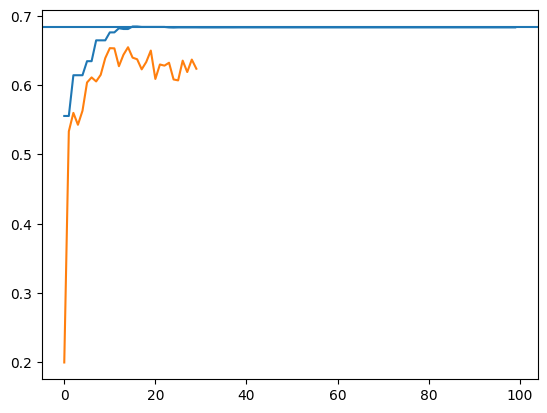

In [184]:
plt.plot(spec_mags[:, 1])
plt.plot(spec_mags_ulam[:, 1])
plt.axhline(ulam_res[0][1])